# Project 2b -- Bayesian Updates Dashboard: Normal Data

We model $X_1, \dots, X_n \overset{iid}{\sim} N(\mu, \sigma^2)$ with **known** $\sigma$, and
use Bayesian updating to learn about the unknown mean $\mu$ (e.g. the mean daily return of a
stock).

**Prior:** $\mu \sim N(\mu_0, \sigma_0^2)$. Defaults: $\mu_0 = 0$, $\sigma_0 = 1$ (Standard
Normal prior).

**Posterior (Normal-Normal conjugacy):** given data with sample mean $\bar{x}$ and size $n$,
$$\mu \mid \text{data} \;\sim\; N(\mu_n, \sigma_n^2)$$
where
$$\frac{1}{\sigma_n^2} = \frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}, \qquad
\mu_n = \sigma_n^2\left(\frac{\mu_0}{\sigma_0^2} + \frac{n\bar{x}}{\sigma^2}\right)$$

**Point estimates:** for a Normal posterior the mode and the mean coincide, so
$$\hat{\mu}_{\text{MAP}} = \hat{\mu}_{\text{Bayes}} = \mu_n$$

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [3]:
def posterior_params_normal(mu0, sigma0, sigma, data):
    """Normal(mu0, sigma0^2) prior + Normal(mu, sigma^2) data -> posterior N(mu_n, sigma_n^2)."""
    data = np.asarray(data)
    n = data.size
    if n == 0:
        return mu0, sigma0

    precision_n = 1 / sigma0**2 + n / sigma**2
    sigma_n2 = 1 / precision_n
    mu_n = sigma_n2 * (mu0 / sigma0**2 + n * data.mean() / sigma**2)
    return mu_n, np.sqrt(sigma_n2)


def parse_data_normal(data_str):
    """Parse a comma/space-separated string of numbers (e.g. '0.123, 1.3812, -0.13')."""
    return np.array([float(x) for x in data_str.replace(",", " ").split()])

In [4]:
def bayes_update_plot_normal(mu0, sigma0, sigma, data):
    mu_n, sigma_n = posterior_params_normal(mu0, sigma0, sigma, data)

    lo = min(mu0 - 4 * sigma0, mu_n - 4 * sigma_n)
    hi = max(mu0 + 4 * sigma0, mu_n + 4 * sigma_n)
    x = np.linspace(lo, hi, 500)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, norm.pdf(x, mu0, sigma0), label=f"Prior: N({mu0:.3f}, {sigma0**2:.3f})", color="tab:blue")
    ax.plot(x, norm.pdf(x, mu_n, sigma_n), label=f"Posterior: N({mu_n:.3f}, {sigma_n**2:.3f})", color="tab:orange")
    ax.axvline(mu_n, color="tab:red", linestyle=":", label=f"MAP = Bayes estimate = {mu_n:.4f}")
    ax.set_xlabel("mu")
    ax.set_ylabel("Density")
    ax.set_title(f"Bayesian Update for Normal Mean (n={data.size}, sigma={sigma})")
    ax.legend()
    plt.show()

    print(f"n = {data.size}, sample mean = {data.mean() if data.size else float('nan'):.4f}")
    print(f"Posterior: N(mu_n={mu_n:.4f}, sigma_n^2={sigma_n**2:.4f})")
    print(f"MAP estimate   = {mu_n:.4f}")
    print(f"Bayes estimate = {mu_n:.4f}  (mode = mean for a Normal posterior)")

## Interactive Dashboard

Running the cell below prompts for the known $\sigma$, the prior parameters $\mu_0$, $\sigma_0$,
and the observed data (comma-separated numbers, e.g. `0.123, 1.3812, -0.13`). Press Enter to
accept the default shown in brackets. The plot then shows the Prior and Posterior PDFs and the
MAP/Bayes estimate for $\mu$.

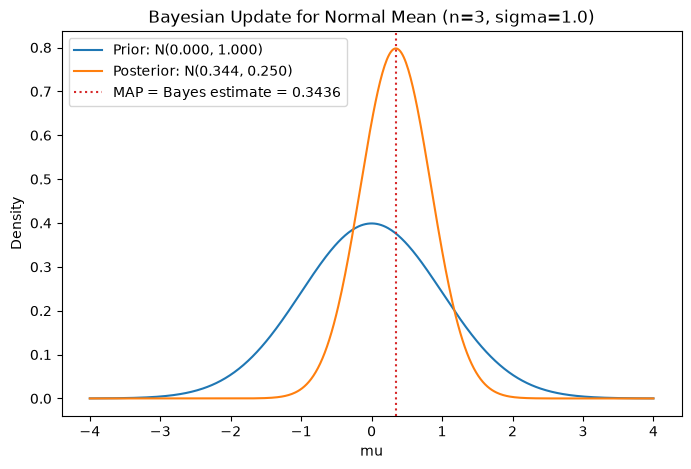

n = 3, sample mean = 0.4581
Posterior: N(mu_n=0.3436, sigma_n^2=0.2500)
MAP estimate   = 0.3436
Bayes estimate = 0.3436  (mode = mean for a Normal posterior)


In [5]:
def run_dashboard_normal():
    sigma = float(input("Known sigma [1]: ") or 1)
    mu0 = float(input("Prior mean mu0 [0]: ") or 0)
    sigma0 = float(input("Prior std sigma0 [1]: ") or 1)
    data_str = input("Data (comma-separated) [0.123, 1.3812, -0.13]: ") or "0.123, 1.3812, -0.13"
    bayes_update_plot_normal(mu0, sigma0, sigma, parse_data_normal(data_str))


run_dashboard_normal()

## Example: Mean of AAPL Daily Returns

Treat AAPL's daily log returns as $N(\mu, \sigma^2)$ with $\sigma$ fixed at the sample standard
deviation, and update a Standard Normal prior $\mu \sim N(0, 1)$ on the full history of returns.

[*********************100%***********************]  1 of 1 completed


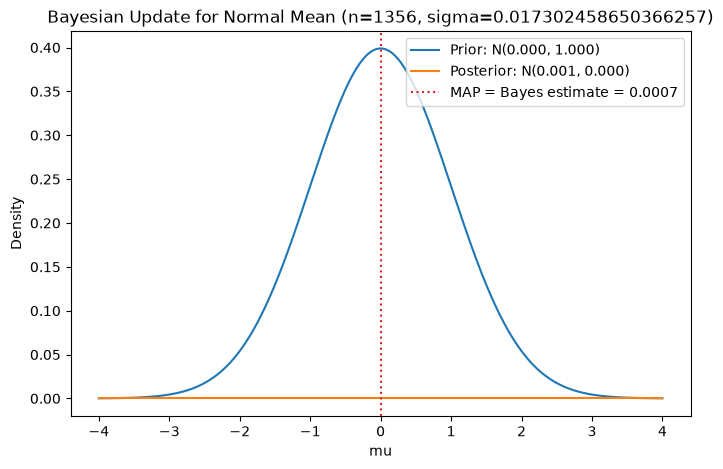

n = 1356, sample mean = 0.0007
Posterior: N(mu_n=0.0007, sigma_n^2=0.0000)
MAP estimate   = 0.0007
Bayes estimate = 0.0007  (mode = mean for a Normal posterior)


In [6]:
import yfinance as yf

close = yf.download("AAPL", start="2021-01-01", end="2026-06-01")["Close"]
returns = np.log(close / close.shift(1)).dropna()["AAPL"].values

sigma_known = returns.std()
bayes_update_plot_normal(0, 1, sigma_known, returns)

## Supplementary: Posterior Convergence to the True Distribution

Suppose we *know* the true mean $\mu$ (and $\sigma$) of the data-generating distribution. We
choose a prior $N(\mu_0, \sigma_0^2)$, generate $n$ random points from $N(\mu, \sigma^2)$, and
compute the posterior from those points. As $n \to \infty$, the posterior should concentrate
around the true $\mu$ regardless of the prior.

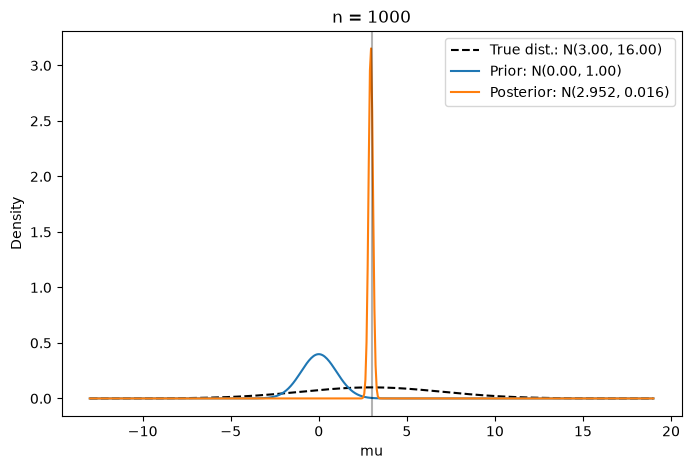

True mu        = 3.0000
Sample mean    = 2.9991
Posterior mean (MAP = Bayes) = 2.9519


In [9]:
def run_supplementary_normal():
    mu_true = float(input("True mean mu [2]: ") or 2)
    sigma = float(input("True sigma [1]: ") or 1)
    mu0 = float(input("Prior mean mu0 [0]: ") or 0)
    sigma0 = float(input("Prior std sigma0 [1]: ") or 1)
    n = int(input("Number of points to generate [10]: ") or 10)

    data = np.random.default_rng().normal(mu_true, sigma, size=n)
    mu_n, sigma_n = posterior_params_normal(mu0, sigma0, sigma, data)

    lo = min(mu0 - 4 * sigma0, mu_true - 4 * sigma, mu_n - 4 * sigma_n)
    hi = max(mu0 + 4 * sigma0, mu_true + 4 * sigma, mu_n + 4 * sigma_n)
    x = np.linspace(lo, hi, 500)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, norm.pdf(x, mu_true, sigma), "k--", label=f"True dist.: N({mu_true:.2f}, {sigma**2:.2f})")
    ax.plot(x, norm.pdf(x, mu0, sigma0), color="tab:blue", label=f"Prior: N({mu0:.2f}, {sigma0**2:.2f})")
    ax.plot(x, norm.pdf(x, mu_n, sigma_n), color="tab:orange", label=f"Posterior: N({mu_n:.3f}, {sigma_n**2:.3f})")
    ax.axvline(mu_true, color="black", alpha=0.3)
    ax.set_xlabel("mu")
    ax.set_ylabel("Density")
    ax.set_title(f"n = {n}")
    ax.legend()
    plt.show()

    print(f"True mu        = {mu_true:.4f}")
    print(f"Sample mean    = {data.mean():.4f}")
    print(f"Posterior mean (MAP = Bayes) = {mu_n:.4f}")


run_supplementary_normal()

### Effect of $n$: Does the Posterior Forget the Prior?

Using the *same* prior and the *same* growing sample (just truncated at different lengths),
compare the posterior for several values of $n$.

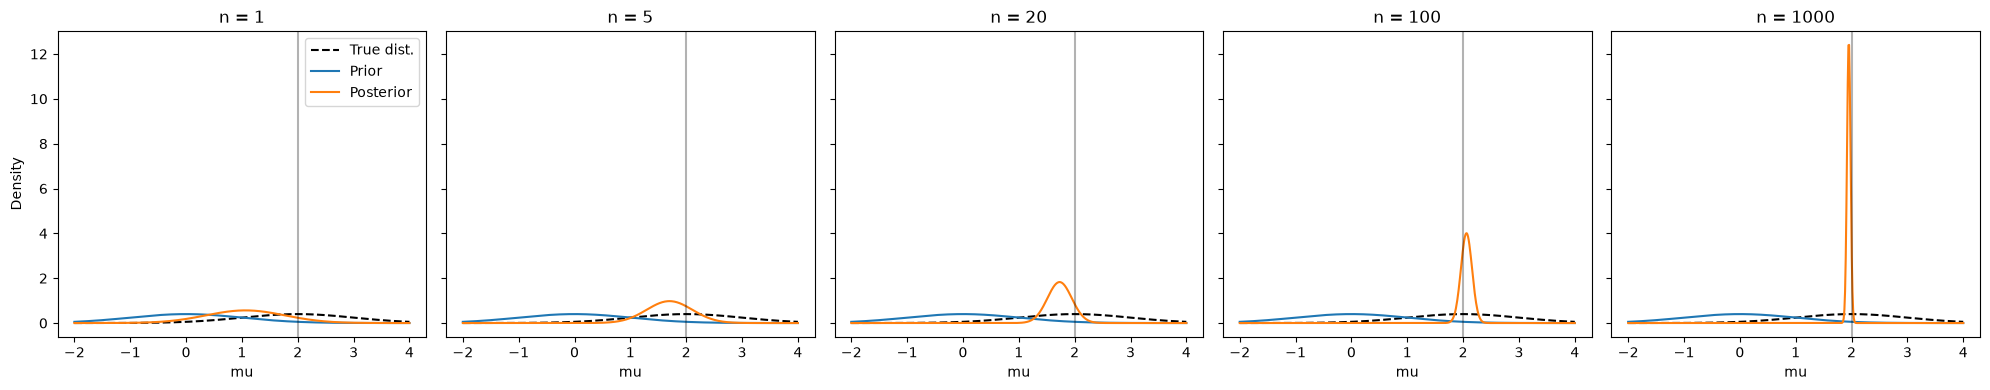

In [7]:
mu_true, sigma = 2.0, 1.0
mu0, sigma0 = 0.0, 1.0
ns = [1, 5, 20, 100, 1000]

rng = np.random.default_rng(0)
full_data = rng.normal(mu_true, sigma, size=max(ns))

x = np.linspace(mu_true - 4 * sigma, mu0 + 4 * sigma0, 500)

fig, axes = plt.subplots(1, len(ns), figsize=(4 * len(ns), 4), sharey=True)
for ax, n in zip(axes, ns):
    mu_n, sigma_n = posterior_params_normal(mu0, sigma0, sigma, full_data[:n])
    ax.plot(x, norm.pdf(x, mu_true, sigma), "k--", label="True dist.")
    ax.plot(x, norm.pdf(x, mu0, sigma0), color="tab:blue", label="Prior")
    ax.plot(x, norm.pdf(x, mu_n, sigma_n), color="tab:orange", label="Posterior")
    ax.axvline(mu_true, color="black", alpha=0.3)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("mu")

axes[0].set_ylabel("Density")
axes[0].legend()
plt.tight_layout()
plt.show()